<a href="https://colab.research.google.com/github/weijenchen519/python-data-analysis/blob/main/%E6%8A%95%E8%B3%87%E7%B5%84%E5%90%88%E6%9C%80%E4%BD%B3%E5%8C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import numpy as np
from scipy.optimize import minimize

In [2]:
#define tickers and time range
tickers=['aapl','amzn','googl','nvda','nflx']
end_date = datetime.today()
start_date = end_date-timedelta(days = 10*365)

#download adjusted close prices
adj_close_df = pd.DataFrame()
for ticker in tickers:
    data= yf.download(ticker,start= start_date, end=end_date, auto_adjust=False)
    adj_close_df[ticker]=data['Adj Close']
print(adj_close_df)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  aapl        amzn       googl        nvda         nflx
Date                                                                   
2015-11-18   26.445259   33.176998   37.740200    0.756944   120.629997
2015-11-19   26.781208   33.063499   37.736725    0.759139   120.220001
2015-11-20   26.898449   33.422501   38.583881    0.765726   123.839996
2015-11-23   26.548964   33.949501   38.568981    0.754261   125.029999
2015-11-24   26.803745   33.557499   38.217911    0.760359   123.309998
...                ...         ...         ...         ...          ...
2025-11-10  269.429993  248.399994  290.100006  199.050003  1120.069946
2025-11-11  275.250000  249.100006  291.309998  193.160004  1136.439941
2025-11-12  273.470001  244.199997  286.709991  193.800003  1157.500000
2025-11-13  272.950012  237.580002  278.570007  186.860001  1154.229980
2025-11-14  272.410004  234.690002  276.410004  190.169998  1112.170044

[2513 rows x 5 columns]


In [3]:
#Calculate Lognormal Returns
log_returns = np.log(adj_close_df/adj_close_df.shift(1))

In [4]:
#drop any missing values
log_returns = log_returns.dropna()

In [5]:
#covariance matrix
cov_matrix = log_returns.cov()*252
print(cov_matrix)

           aapl      amzn     googl      nvda      nflx
aapl   0.084646  0.054867  0.051364  0.078370  0.053236
amzn   0.054867  0.107626  0.060605  0.088881  0.073672
googl  0.051364  0.060605  0.082615  0.078451  0.054639
nvda   0.078370  0.088881  0.078451  0.245353  0.093006
nflx   0.053236  0.073672  0.054639  0.093006  0.182149


In [6]:
#calculate portflio standard deviation
def std(weights, cov_matrix):
  var = weights.T@cov_matrix@weights
  return np.sqrt(var)

In [7]:
#calculate expected return
def expected_return(weights, log_returns):
  expected_return = np.sum(log_returns.mean()*weights)*252
  return expected_return

In [8]:
#calculate sharpe ratio
def sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
  return (expected_return(weights, log_returns)-risk_free_rate)/std(weights, cov_matrix)

In [9]:
#set a risk free rate
risk_free_rate = 0.03

#set a constraint for this portfolio
#1.cannot short stocks,which means the weight cannot be less than 0
#2.one stock cannot weight more than 0.5
#3.the weight sum is equal to 1
constraints = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}
bounds = [(0, 0.5) for _ in range(len(tickers))]

#set initial_weights
initial_weights = np.array([1/len(tickers)]*len(tickers))
print(initial_weights)

[0.2 0.2 0.2 0.2 0.2]


In [10]:
#find the optimize weight to maximize sharpe ratio
def neg_sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return -sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate)
optimized_results = minimize(neg_sharpe_ratio, initial_weights, args=(log_returns, cov_matrix, risk_free_rate),
                             method='SLSQP', constraints=constraints, bounds=bounds)

In [11]:
#Analyze the Optimal Portfolio
optimal_weights = optimized_results.x #.x finds the optimize solution

print("Optimal Weights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

optimal_portfolio_return = expected_return(optimal_weights, log_returns=log_returns)
optimal_portfolio_volatility = std(optimal_weights, cov_matrix)
optimal_sharpe_ratio = sharpe_ratio(optimal_weights, log_returns, cov_matrix, risk_free_rate)

print(f"Expected Annual Return: {optimal_portfolio_return:.4f}")
print(f"Expected Volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

Optimal Weights:
aapl: 0.4115
amzn: 0.0000
googl: 0.0757
nvda: 0.5000
nflx: 0.0128
Expected Annual Return: 0.3915
Expected Volatility: 0.3456
Sharpe Ratio: 1.0459


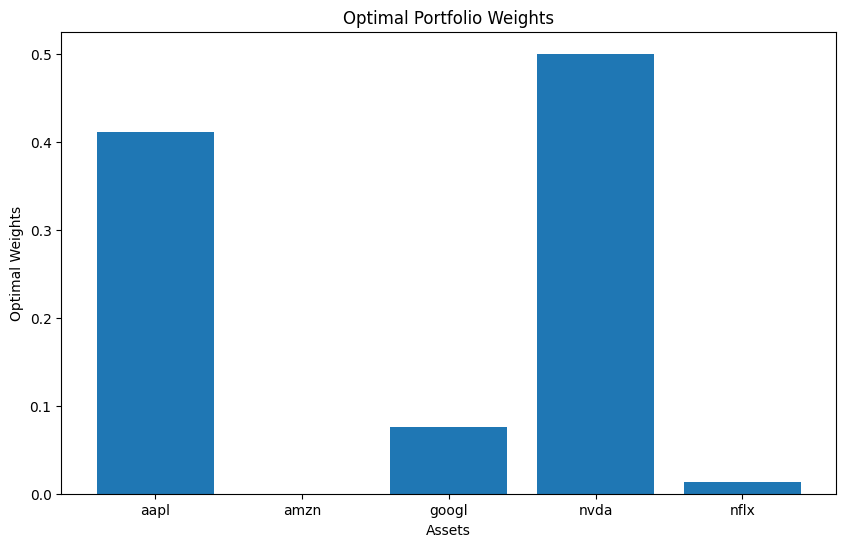

In [12]:
#plot the final portfolio
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(tickers, optimal_weights)

plt.xlabel('Assets')
plt.ylabel('Optimal Weights')
plt.title('Optimal Portfolio Weights')

plt.show()